**Customer Segmentation**

---



**Project Objective**


---
The objective of this project is to segment customers based on purchasing behavior using K-Means Clustering. By identifying distinct customer groups, businesses can develop targeted marketing, retention, and profitability strategies.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv("Sample - Superstore.csv",encoding="latin1")

**Dataset Information**

Rows: 9,994
Columns: 21

Customer Records:
- Customer ID
- Customer Name

Transactional Features:
- Sales
- Profit
- Quantity
- Order Date

Business Segment:
- Consumer
- Corporate
- Home Office

---



**Data Understanding**

In [3]:
# Data overview
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# Data Shape
df.shape

(9994, 21)

In [5]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
# Data type
df_datatype=df.dtypes
df_datatype.value_counts()

,count
object,15
int64,3
float64,3


In [7]:
# Convert Date
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [8]:
# Null Values
df.isnull().sum().sum()

np.int64(0)

In [9]:
# Duplicate Values
df.duplicated().sum()

np.int64(0)

In [10]:
# Unique Customer
df["Customer ID"].nunique()

793

**Data Cleaning**

---



In [11]:
# Creating Customer Level Dataset
cust_df=df.groupby(["Customer ID","Customer Name"]).agg({"Sales":"sum","Profit":"sum","Order ID":"nunique"}).reset_index()

In [12]:
cust_df.columns=["Customer Id","Customer Name","Total Sale","Total Profit","Total Orders"]

In [13]:
cust_df.head()

,Customer Id,Customer Name,Total Sale,Total Profit,Total Orders
0,AA-10315,Alex Avila,5563.560,-362.8825,5
1,AA-10375,Allen Armold,1056.390,277.3824,9
2,AA-10480,Andrew Allen,1790.512,435.8274,4
3,AA-10645,Anna Andreadi,5086.935,857.8033,6
4,AB-10015,Aaron Bergman,886.156,129.3465,3


In [14]:
# Recency
lastest_date=df["Order Date"].max()
last_purchase=df.groupby("Customer ID")["Order Date"].max()
recency=lastest_date-last_purchase
cust_df["Recency"]=recency.values
cust_df["Recency"]=cust_df["Recency"].dt.days

**Recency Calculation**

Recency represents the number of days since a customer's last purchase.

Lower Recency → More Active Customer

Higher Recency → Less Active Customer

In [15]:
cust_df.head()

,Customer Id,Customer Name,Total Sale,Total Profit,Total Orders,Recency
0,AA-10315,Alex Avila,5563.560,-362.8825,5,184
1,AA-10375,Allen Armold,1056.390,277.3824,9,19
2,AA-10480,Andrew Allen,1790.512,435.8274,4,259
3,AA-10645,Anna Andreadi,5086.935,857.8033,6,55
4,AB-10015,Aaron Bergman,886.156,129.3465,3,415


In [16]:
# Feature Selection
X=cust_df[["Total Sale","Total Profit","Total Orders","Recency"]]

In [17]:
X.head()

,Total Sale,Total Profit,Total Orders,Recency
0,5563.560,-362.8825,5,184
1,1056.390,277.3824,9,19
2,1790.512,435.8274,4,259
3,5086.935,857.8033,6,55
4,886.156,129.3465,3,415


In [18]:
# Feature Scaling
scaler=StandardScaler()
X=scaler.fit_transform(X)

In [19]:
X[:5]

array([[ 1.01511197, -0.81016078, -0.51642886,  0.19988856],
       [-0.70059002, -0.09373862,  1.05264427, -0.68676201],
       [-0.4211387 ,  0.08355286, -0.90869715,  0.60291154],
       [ 0.83367962,  0.55572131, -0.12416058, -0.49331098],
       [-0.76539139, -0.25938287, -1.30096543,  1.44119935]])

In [20]:
# Elbow Method
wcss=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

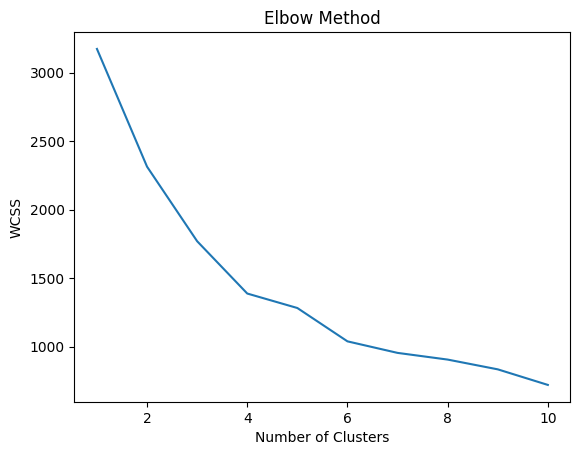

In [21]:
plt.plot(range(1,11),wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [43]:
model=KMeans(n_clusters=4)
model.fit(X)

KMeans(n_clusters=4)

In [44]:
cluster=model.predict(X)

In [45]:
from sklearn.metrics import silhouette_score
silhouette_score(X, cluster)

np.float64(0.3687229453365535)

**Cluster Selection**

The Elbow Method suggested an optimal cluster count of 4. Silhouette Score analysis confirmed that 4 clusters provided the best balance between cohesion and separation.

In [46]:
cust_df["Clusters"]=cluster

In [47]:
cust_df.head()

,Customer Id,Customer Name,Total Sale,Total Profit,Total Orders,Recency,Clusters
0,AA-10315,Alex Avila,5563.560,-362.8825,5,184,1
1,AA-10375,Allen Armold,1056.390,277.3824,9,19,1
2,AA-10480,Andrew Allen,1790.512,435.8274,4,259,1
3,AA-10645,Anna Andreadi,5086.935,857.8033,6,55,1
4,AB-10015,Aaron Bergman,886.156,129.3465,3,415,2


In [52]:
cust_df.groupby("Clusters").agg({"Total Sale":"mean","Total Profit":"mean","Total Orders":"mean","Recency":"mean"})

,Total Sale,Total Profit,Total Orders,Recency
Clusters,,,,
0,6778.528040,-2105.638385,7.200000,70.700000
1,2039.597729,213.158845,6.161905,85.620952
2,1449.635738,153.183274,3.685185,530.046296
3,6673.434516,1428.982871,8.800000,91.457143


**Cluster Characteristics**

The following table summarizes the average customer behavior for each cluster.

In [53]:
cust_df["Clusters"].value_counts()

,count
Clusters,
1,525
3,140
2,108
0,20


In [56]:
cust_df['Clusters'] = cust_df['Clusters'].replace({
    0: "Unprofitable High-Value Customers",
    1: "Regular Customers",
    2: "Inactive Customers",
    3: "Loyal High-Value Customers"
})


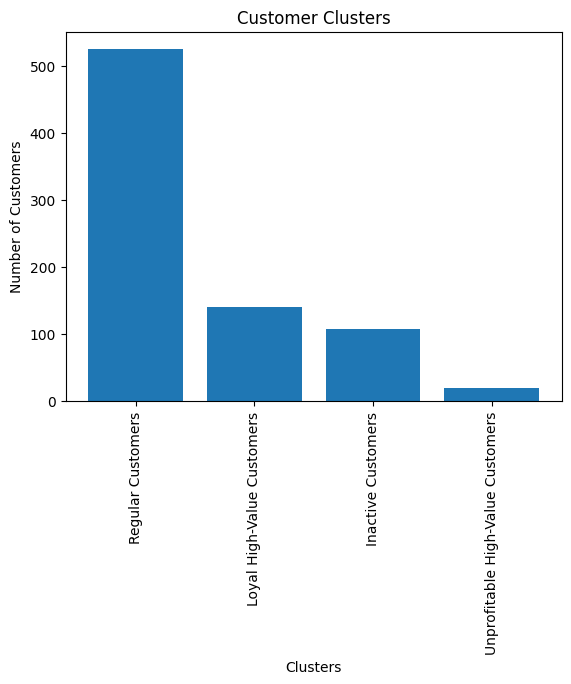

In [68]:
plt.bar(cust_df["Clusters"].value_counts().index,cust_df["Clusters"].value_counts())
plt.title("Customer Clusters")
plt.xlabel("Clusters")
plt.ylabel("Number of Customers")
plt.xticks(rotation=90)
plt.show()

**Insights**


Regular Customers represent approximately two-thirds of the customer base, making them the largest segment. Loyal High-Value Customers account for a smaller portion of customers but contribute significantly to revenue and profitability.

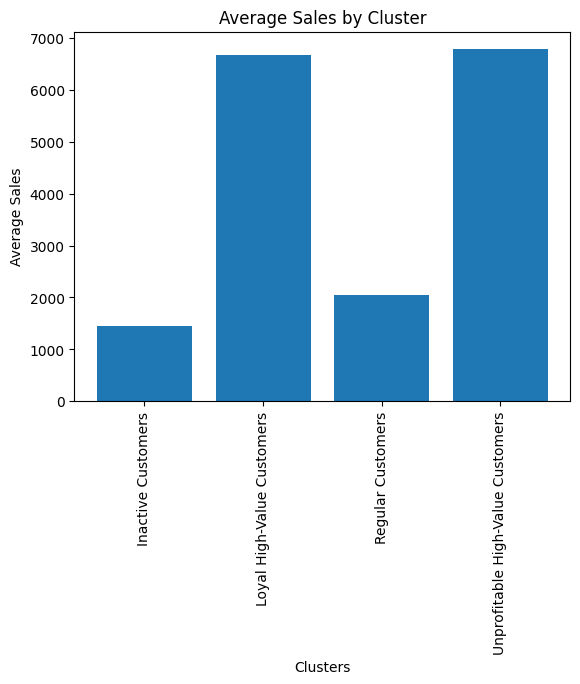

In [69]:
plt.bar(cust_df.groupby("Clusters")["Total Sale"].mean().index,cust_df.groupby("Clusters")["Total Sale"].mean())
plt.title("Average Sales by Cluster")
plt.xlabel("Clusters")
plt.ylabel("Average Sales")
plt.xticks(rotation=90)
plt.show()

**Insights**

Unprofitable High-Value Customers and Loyal High-Value Customers generate the highest average sales. However, the profitability of these two groups differs substantially, highlighting the importance of evaluating profit alongside revenue.

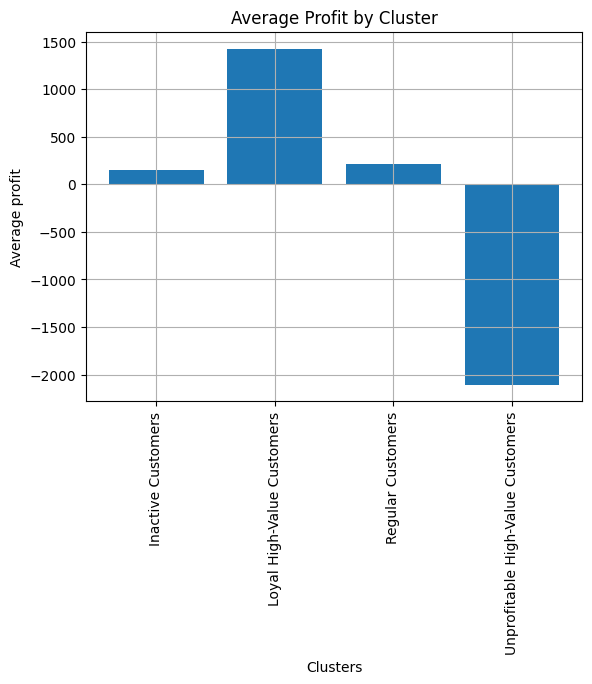

In [73]:
plt.bar(cust_df.groupby("Clusters")["Total Profit"].mean().index,cust_df.groupby("Clusters")["Total Profit"].mean())
plt.title("Average Profit by Cluster")
plt.grid()
plt.xlabel("Clusters")
plt.ylabel("Average profit")
plt.xticks(rotation=90)
plt.show()

**Insights**

Loyal High-Value Customers generate the highest average profit, whereas Unprofitable High-Value Customers generate negative profit despite high sales volumes. This suggests potential issues related to discounting, product mix, or operational costs.

**Business Insights**

---



**Loyal High-Value Customers**

* High sales, high profit, and frequent purchases.
* Ideal candidates for loyalty programs and VIP rewards.

**Regular Customers**

* Largest customer segment.
* Opportunity for upselling and cross-selling initiatives.

**Inactive Customers**

* Low engagement and very high recency.
* Suitable targets for reactivation campaigns and promotional offers.

**Unprofitable High-Value Customers**

* Generate high sales but negative profit.
* Require review of discount strategies, pricing, and fulfillment costs.

---




**Conclusion**

This project applied K-Means Clustering to segment customers based on purchasing behavior, including sales, profit, order frequency, and recency. Customer-level features were created using transactional data, and feature scaling was performed prior to clustering.

The Elbow Method and Silhouette Score analysis suggested four meaningful customer segments. These segments were identified as Loyal High-Value Customers, Regular Customers, Inactive Customers, and Unprofitable High-Value Customers.

The analysis revealed that Regular Customers represent the majority of the customer base, while Loyal High-Value Customers contribute significantly to revenue and profitability. Inactive Customers provide opportunities for re-engagement, whereas Unprofitable High-Value Customers require strategic actions to improve margins and profitability.

The segmentation results can help businesses design targeted marketing campaigns, improve customer retention, and optimize profitability through data-driven decision-making.